<a href="https://colab.research.google.com/github/bpizarrogalleguillos/IAmetodologia2025/blob/main/Taller_Supervisado_2_Clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
# Instalación de librerías necesarias
!pip install -q pandas scikit-learn matplotlib seaborn

#Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

# Librerías Interactivas
import ipywidgets as widgets
from ipywidgets import interact
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm
from ipywidgets import interact

# Gradio
!pip install gradio
import gradio as gr

Flujo completo de ML en Radiología: Diagnóstico de Neumonía

""" Flujo de trabajo clásico en Machine Learning:

    Recolección de datos → Dataset clínico simulado.
    Preprocesamiento → Codificación de variables categóricas, limpieza.
    División del dataset → Train/Test split.
    Entrenamiento → Modelos supervisados.
    Evaluación → Métricas: accuracy, recall, curva ROC. """


In [80]:
!wget https://raw.githubusercontent.com/bpizarrogalleguillos/IAmetodologia2025/main/data_2.csv

--2025-06-12 22:11:25--  https://raw.githubusercontent.com/bpizarrogalleguillos/IAmetodologia2025/main/data_2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17303 (17K) [text/plain]
Saving to: ‘data_2.csv.1’

data_2.csv.1        100%[===================>]  16.90K  --.-KB/s    in 0.002s  

2025-06-12 22:11:25 (10.7 MB/s) - ‘data_2.csv.1’ saved [17303/17303]



# Cargar base de datos

In [81]:
pd.read_csv("data_2.csv")
data = pd.read_csv("data_2.csv")
data

,edad,sexo,fiebre,temperatura,tos,infiltrado_rx,engrosamiento_parietal,foco_condensacion,patron_intersticial,derrame_pleural,broncograma_aereo,cruza_cisuras,leucocitosis,pcr,indice_rx,diagnostico_neumonia,ingreso_uci,intubacion,mortalidad
0,58,F,1,39.0,1,0,0,1,0,1,0,0,12568,44.8,10.7536,1,1,1,1
1,48,F,1,38.4,0,1,0,0,0,0,0,0,11522,37.0,7.1544,1,0,0,0
2,39,F,1,38.6,1,0,0,1,1,0,0,0,15715,48.2,10.5530,1,1,1,1
3,21,M,1,38.3,1,0,1,0,0,0,0,0,13450,47.1,7.5450,1,1,1,0
4,30,M,0,37.1,1,0,0,1,0,0,0,0,6462,18.6,5.2224,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,47,F,1,38.8,0,1,0,1,0,0,0,0,12572,42.5,10.6394,1,1,1,0
296,35,F,1,38.4,1,0,0,0,0,0,0,0,12889,43.7,6.2628,1,1,1,1
297,86,M,0,36.6,1,1,0,0,1,0,0,0,8143,24.9,4.8736,0,0,0,0
298,56,M,1,38.1,0,1,0,0,1,0,1,0,13457,40.2,10.2014,1,0,1,0


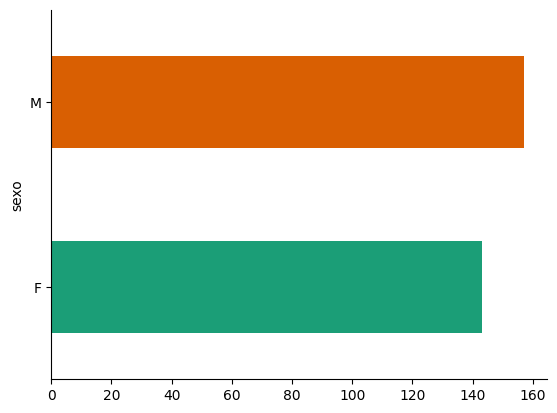

In [82]:

data.groupby('sexo').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

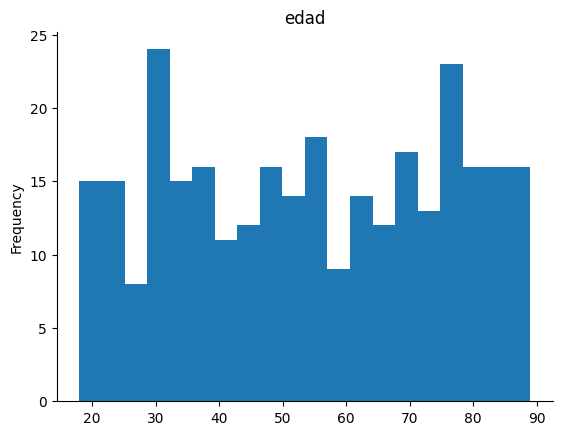

In [83]:
data['edad'].plot(kind='hist', bins=20, title='edad')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

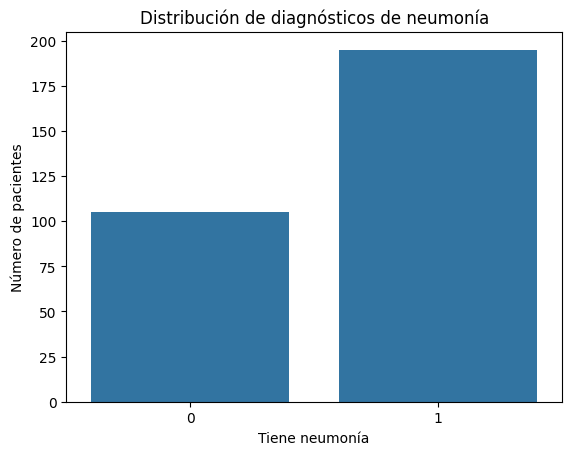

In [84]:

sns.countplot(x='diagnostico_neumonia', data=data)
plt.title("Distribución de diagnósticos de neumonía")
plt.xlabel("Tiene neumonía")
plt.ylabel("Número de pacientes")
plt.show()

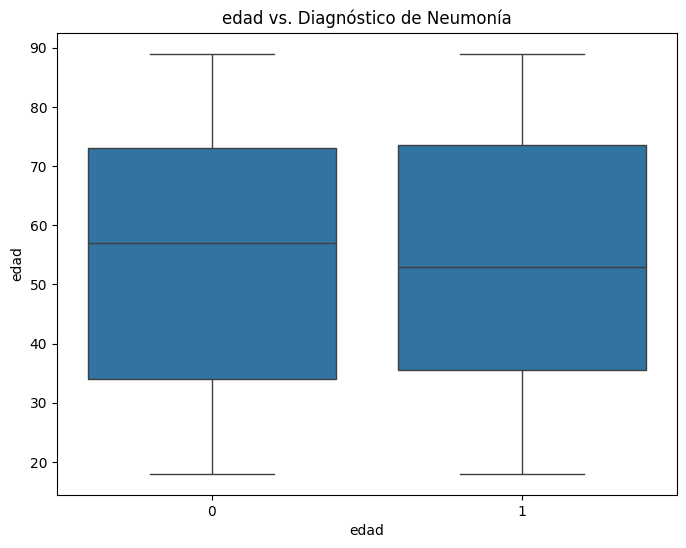

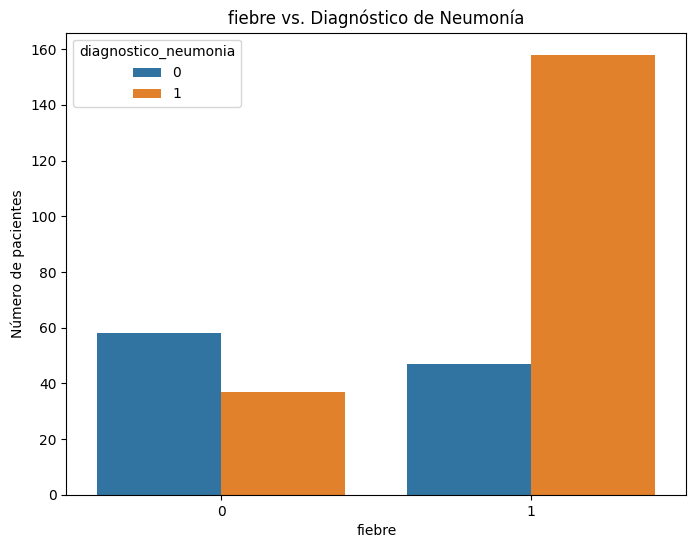

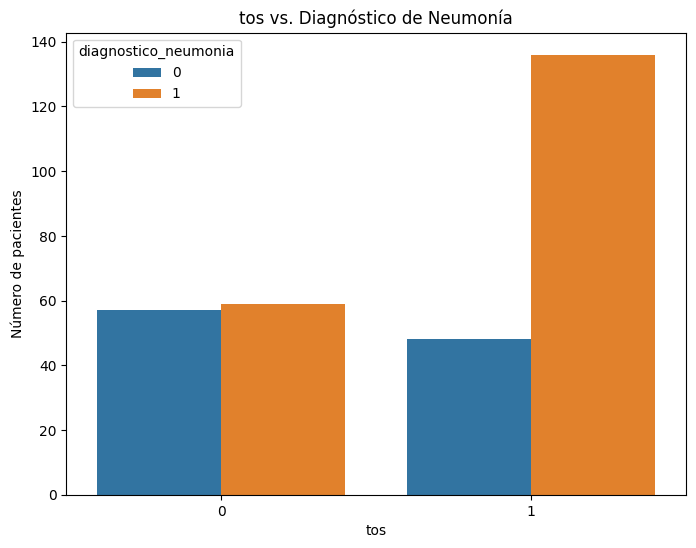

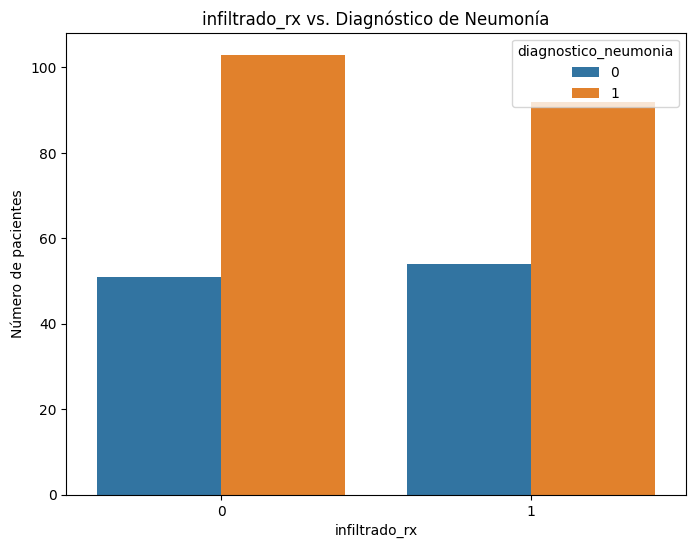

In [85]:
# Lista de variables a comparar con el diagnóstico de neumonía
features_to_plot = ['edad', 'fiebre', 'tos', 'infiltrado_rx']

for feature in features_to_plot:
    plt.figure(figsize=(8, 6))

    if data[feature].nunique() <= 2:  # Variables binarias o categóricas simples
        sns.countplot(x=feature, hue='diagnostico_neumonia', data=data)
        plt.ylabel('Número de pacientes')
    else:  # Variables continuas (como edad)
        sns.boxplot(x='diagnostico_neumonia', y=feature, data=data)
        plt.ylabel(feature)

    plt.title(f'{feature} vs. Diagnóstico de Neumonía')
    plt.xlabel(feature)
    plt.show()

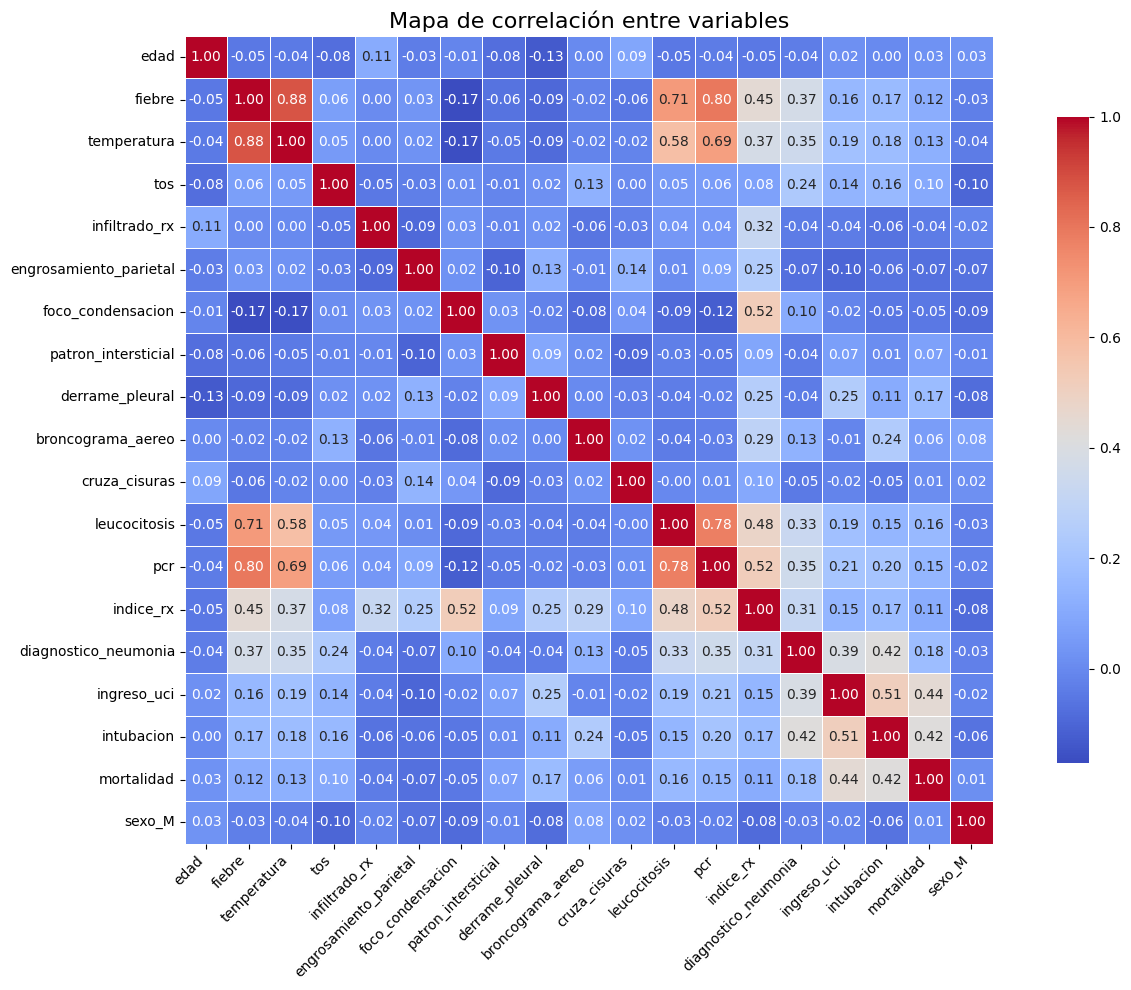

In [86]:
#@title 📊 Mapa de correlación entre variables

# Asegurar que todas las variables categóricas estén codificadas numéricamente
encoded_data = pd.get_dummies(data, columns=['sexo'], drop_first=True)

# Calcular matriz de correlación
correlation_matrix = encoded_data.corr()

# Graficar heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    square=True,
    cbar_kws={"shrink": .8},
    linewidths=0.5
)
plt.title("Mapa de correlación entre variables", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Pre procesamiento

Definiremos que nuestro objetivo será predecir el diagnóstico de neumonía a partir de una combinación de parámetros clínicos e imagneológicos. Por lo tanto debemos eliminar variables que son outcomes en si mismos como mortalidad, intubación e ingreso a UCI, los cuales también pueden ser variables a predecir.

In [87]:
#@title 🔄 Preprocesamiento de datos

# Convertir variable categórica 'sexo' a variable numérica
encoded_data = pd.get_dummies(data, columns=['sexo'], drop_first=True)

# Eliminar variables que no deben ser usadas como predictoras del diagnóstico
### Aquí puedes remover de la lista aquella variable que quieras predecir en vez de neumonía ##
### y debes agregar neumonía a la lista de variables a excluir ###
variables_a_excluir = ['ingreso_uci', 'intubacion', 'mortalidad']
X = encoded_data.drop(columns=['diagnostico_neumonia'] + variables_a_excluir)

# Variable objetivo
y = encoded_data['diagnostico_neumonia'] ### Aquí puedes cambiar la variable por otra que sea de tu interés


## División Train y Test

Este paso es fundamental para poder evaluar el rendimiento del modelo y ver su capacidad de "generalizar". Es importante que no haya ningun tipo de mezcla entre estos datasets ni tampoco fuga de información de uno a otro.

In [88]:
# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## La nomeclatura habitual es que X corresponda a las variables independientes
## Mientras que Y corresponde a las variables dependientes o outcomes que quiero predecir.

In [89]:
X_train.shape
X_test.shape

### Desafío ###
### ¿Cómo podrías calcular la dimension de y_train e y_test? ###
### ¿Cómo esperas que sean en comparación a X_train y X_test?

(90, 15)

In [90]:
y_train

,diagnostico_neumonia
194,1
101,0
68,0
224,1
37,1
...,...
188,1
71,0
106,0
270,0


# Regresión Logística

Para ejemplificar un modelo con el cuál podemos predecir un outcome usaremos una regresión logística.



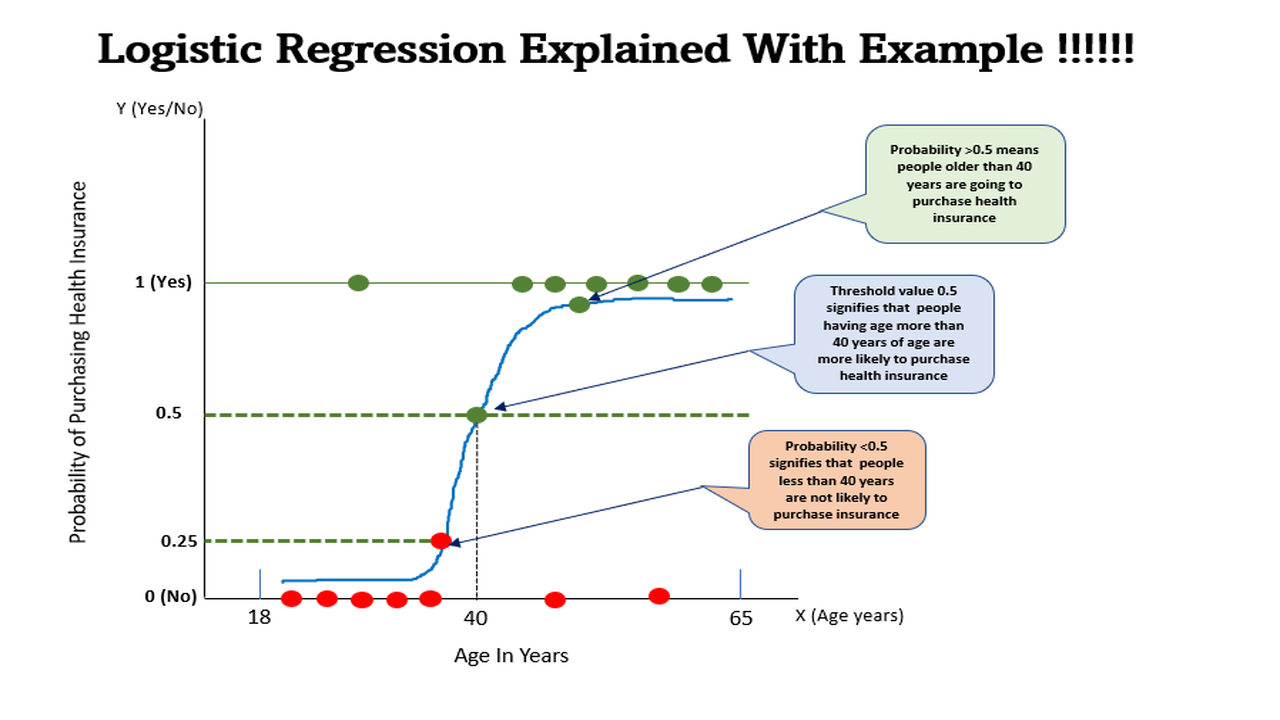

#Ejemplo de regresión logística: Neumonía vs. PCR

Por ejemplo podríamos querer buscar un modelo que permita predecir el diagnóstico de neumonía basado en el nivel de PCR

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


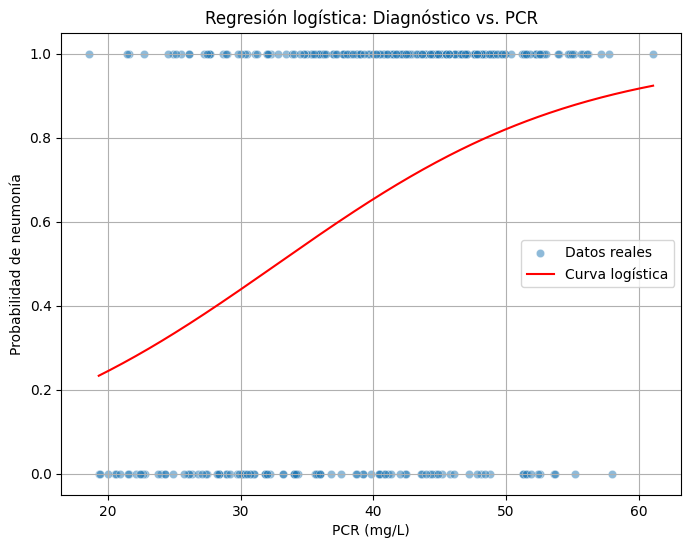

In [91]:
from sklearn.linear_model import LogisticRegression

# Variables
X_log = X_train[['pcr']] # Variable independiente
y_log = y_train # Variable dependiente o outcome

# Modelo
modelo_log = LogisticRegression() # Aquí estamos utilizando la clase correspondiente de sklearn - librería con la cual podemos implementar fácilmente el método
modelo_log.fit(X_log, y_log) # Posteriormente ajustamos del modelo usando el método "fit" de la clase LogisticRegression()

# Predicciones (probabilidad)
x_range = np.linspace(X_test['pcr'].min(), X_test['pcr'].max(), 300).reshape(-1, 1)
y_pred_prob = modelo_log.predict_proba(x_range)[:, 1]

# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x='pcr', y='diagnostico_neumonia', data=data, label='Datos reales', alpha=0.5)
plt.plot(x_range, y_pred_prob, color='red', label='Curva logística')
plt.xlabel('PCR (mg/L)')
plt.ylabel('Probabilidad de neumonía')
plt.title('Regresión logística: Diagnóstico vs. PCR')
plt.legend()
plt.grid(True)
plt.show()

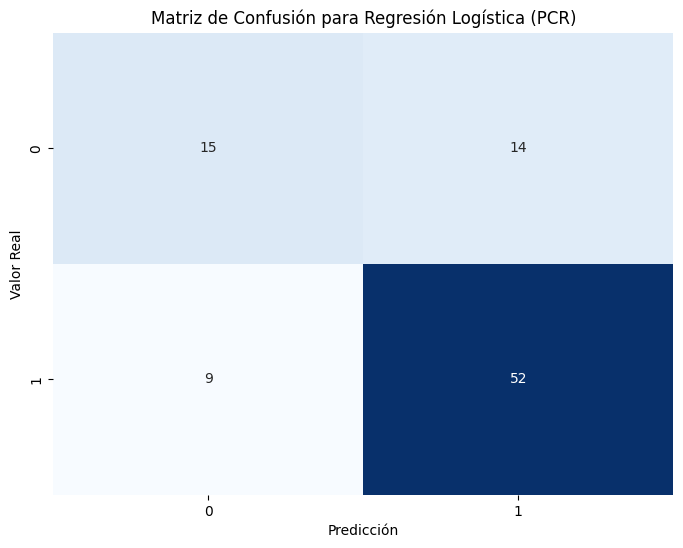


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.62      0.52      0.57        29
           1       0.79      0.85      0.82        61

    accuracy                           0.74        90
   macro avg       0.71      0.68      0.69        90
weighted avg       0.74      0.74      0.74        90



In [92]:
# Hacer predicciones en el conjunto de prueba
y_pred_log = modelo_log.predict(X_test[['pcr']])

# Generar la matriz de confusión
cm = confusion_matrix(y_test, y_pred_log)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Regresión Logística (PCR)')
plt.show()

# Mostrar el reporte de clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_log))

## Cómo se relacionan estás métricas de rendimiento con las que estamos acostumbrados en medicina

¿Qué es Precision, Recall, F1- Score?
Son métricas que nos permiten definir que tan bueno es nuestro modelo para predecir la variable outcome.

En medicina no estamos muy acostumbrados a estas métricas que son utilizadas en machine learning, pero también podemos calcular métricas como sensibilidad, especificidad, etc.

In [93]:
# Calcular las métricas a partir de la matriz de confusión
tn, fp, fn, tp = cm.ravel()

# Sensibilidad (Sensitivity or Recall): TP / (TP + FN)
sensibilidad = tp / (tp + fn) if (tp + fn) > 0 else 0

# Especificidad (Specificity): TN / (TN + FP)
especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0

# Valor Predictivo Positivo (Positive Predictive Value - VPP): TP / (TP + FP)
vpp = tp / (tp + fp) if (tp + fp) > 0 else 0

# Valor Predictivo Negativo (Negative Predictive Value - VPN): TN / (TN + FN)
vpn = tn / (tn + fn) if (tn + fn) > 0 else 0

# Likelihood Ratio Positivo (LR+): Sensibilidad / (1 - Especificidad)
lr_positivo = sensibilidad / (1 - especificidad) if (1 - especificidad) > 0 else float('inf')

# Likelihood Ratio Negativo (LR-): (1 - Sensibilidad) / Especificidad
lr_negativo = (1 - sensibilidad) / especificidad if especificidad > 0 else float('inf')

print(f"Sensibilidad: {sensibilidad:.4f}")
print(f"Especificidad: {especificidad:.4f}")
print(f"VPP: {vpp:.4f}")
print(f"VPN: {vpn:.4f}")
print(f"Likelihood Ratio +: {lr_positivo:.4f}")
print(f"Likelihood Ratio -: {lr_negativo:.4f}")

Sensibilidad: 0.8525
Especificidad: 0.5172
VPP: 0.7879
VPN: 0.6250
Likelihood Ratio +: 1.7658
Likelihood Ratio -: 0.2852


In [94]:
### Desafío ###
### ¿Podrías intentar hacer la analogía entre las métricas usadas en machine learning y las métricas usadas en medicina?


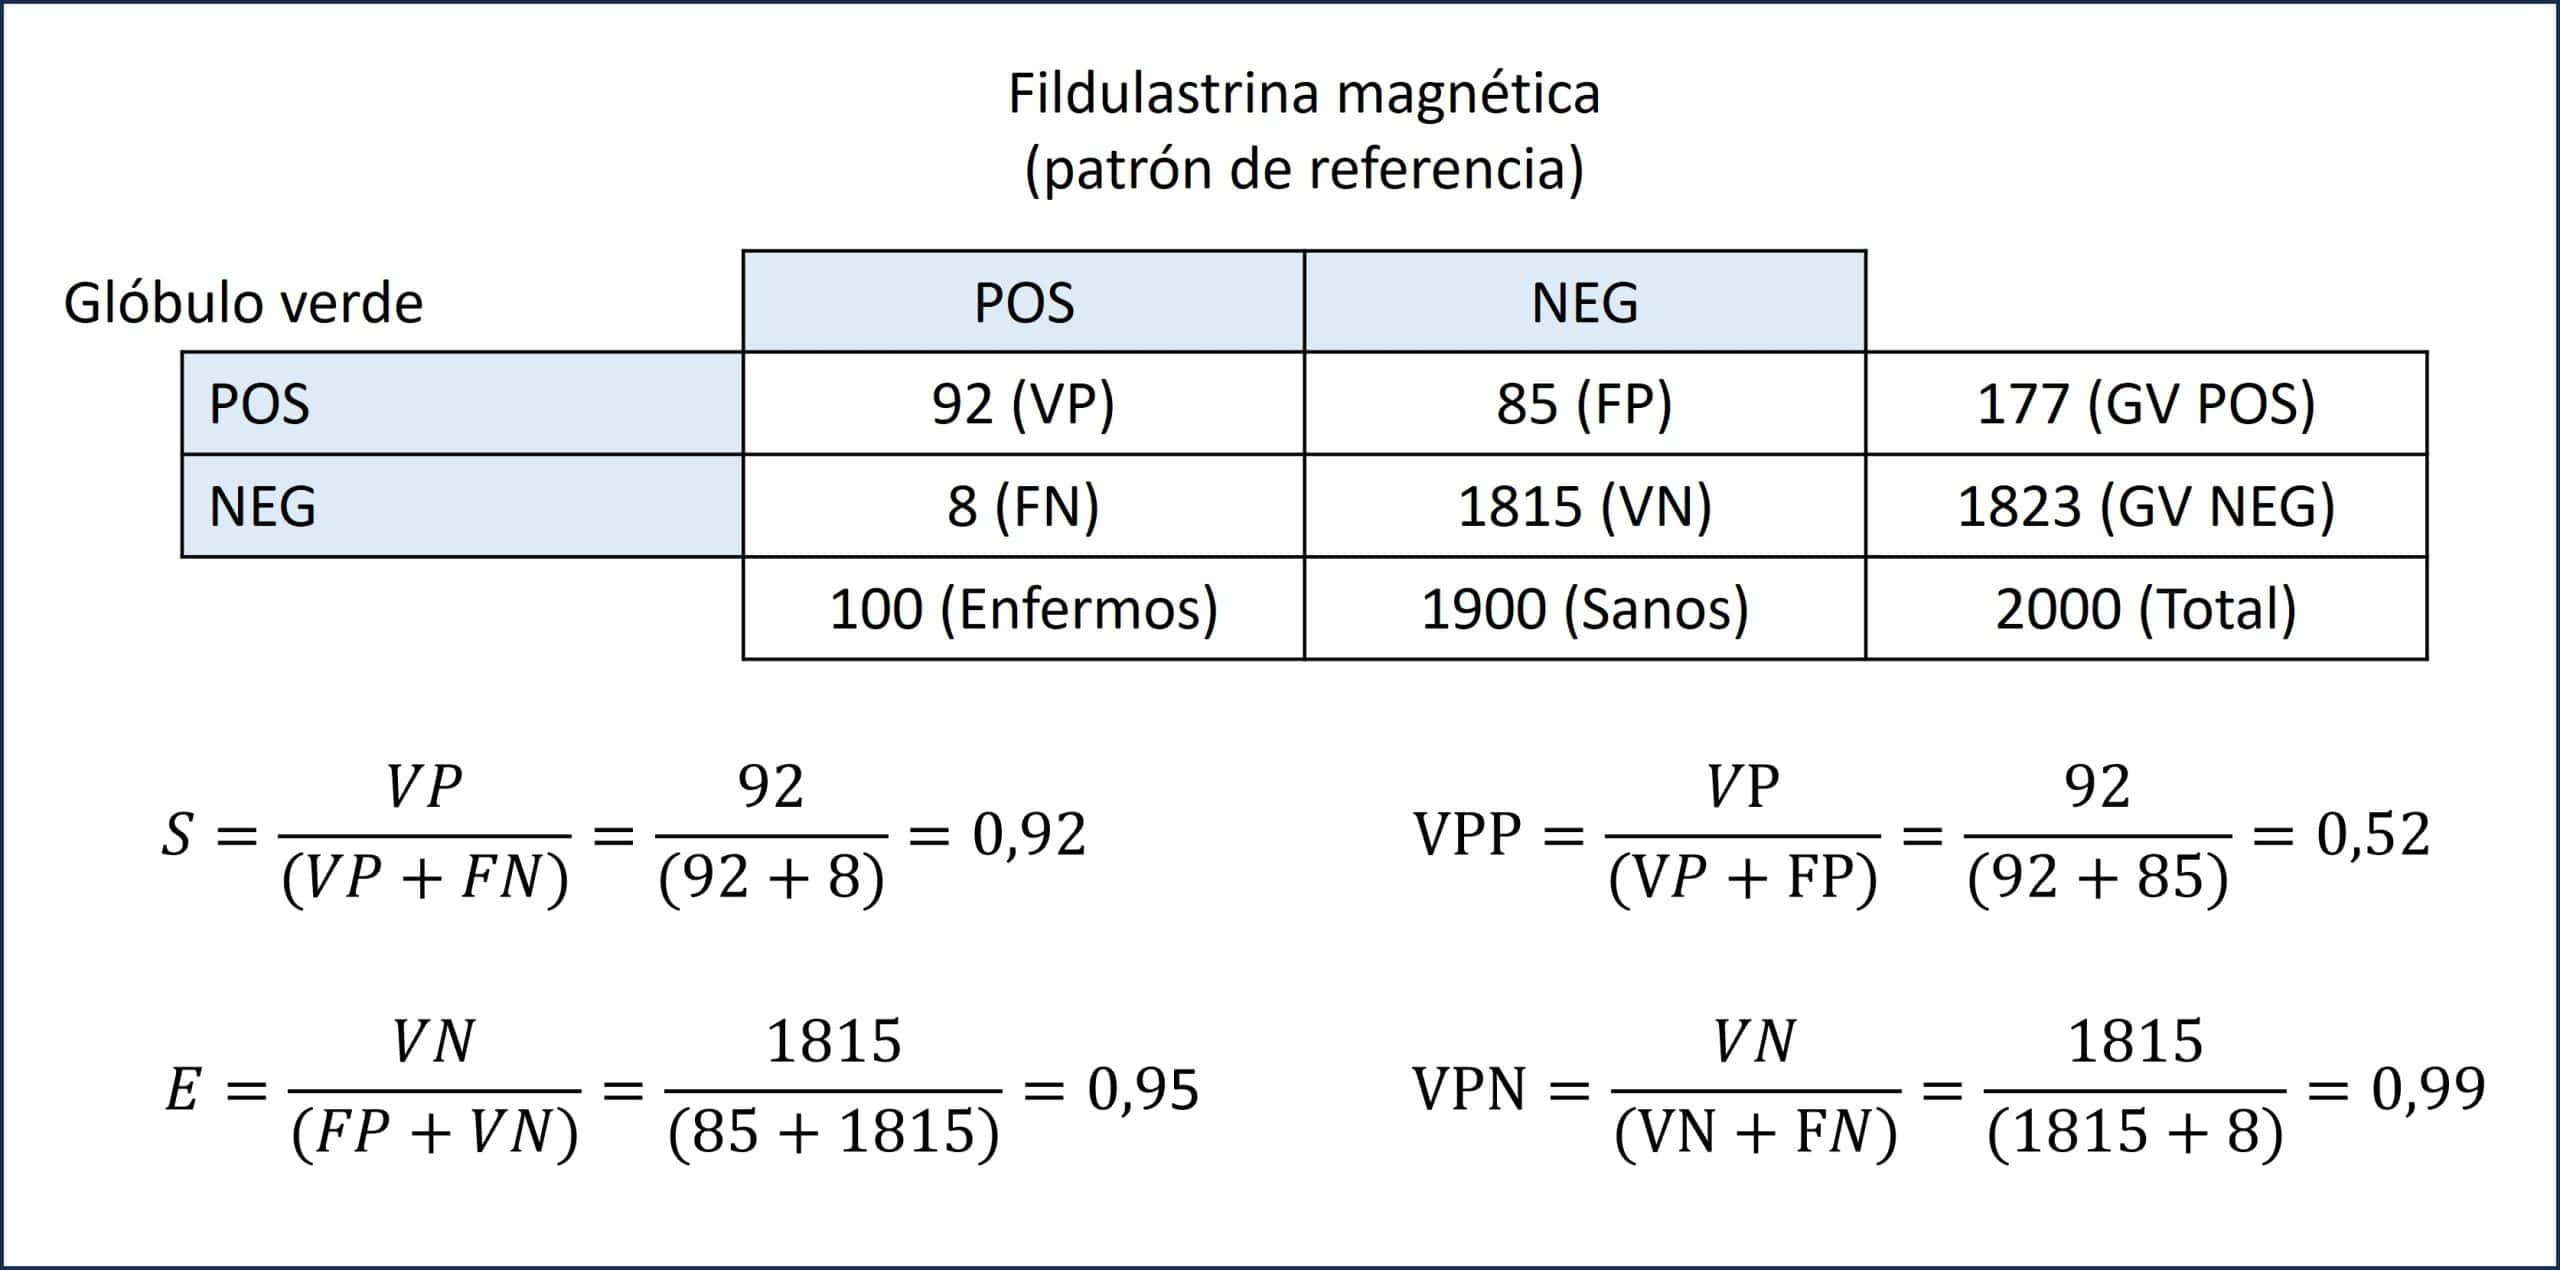

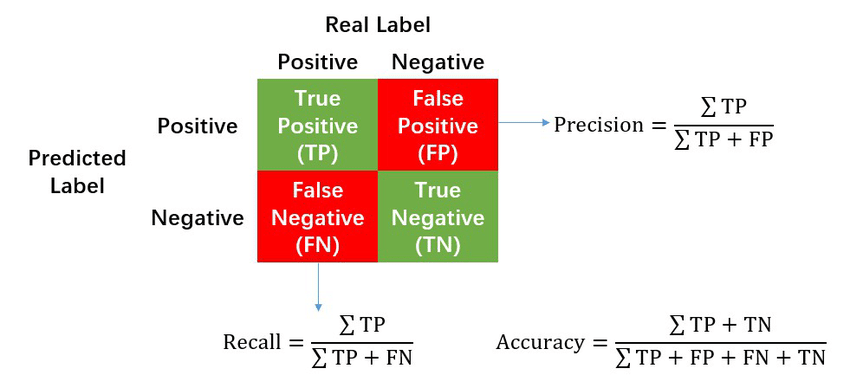

# Curva ROC


*   La línea diagonal negra punteada representa un modelo que adivina al azar (AUC = 0.5).
*   La curva azul muestra el rendimiento de tu modelo. Mientras más se aleje de la diagonal (hacia la esquina superior izquierda), mejor es el modelo.

El AUC (Área Bajo la Curva) es un valor resumen que indica qué tan bien el modelo puede separar las dos clases:

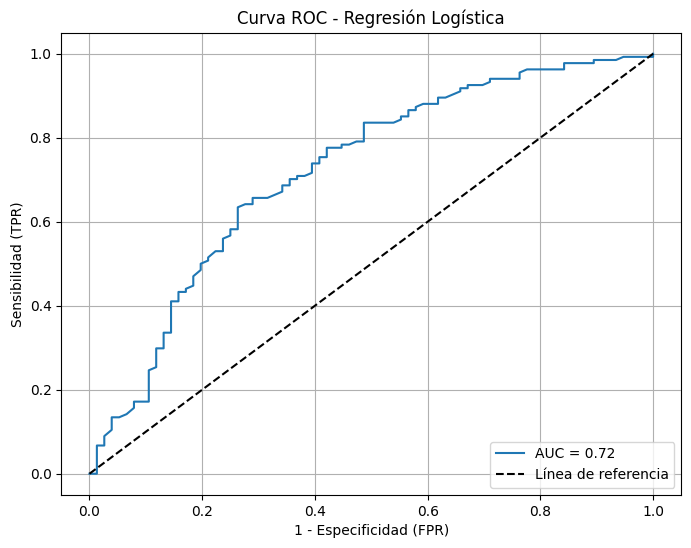

In [95]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Obtener las probabilidades de predicción para la clase positiva
y_probs = modelo_log.predict_proba(X_log)[:, 1]  # Probabilidades de clase 1

# 2. Calcular los valores de la curva ROC
fpr, tpr, thresholds = roc_curve(y_log, y_probs)

# 3. Calcular el área bajo la curva (AUC)
auc = roc_auc_score(y_log, y_probs)

# 4. Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', label='Línea de referencia')
plt.xlabel('1 - Especificidad (FPR)')
plt.ylabel('Sensibilidad (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [96]:
# Obtener probabilidades predichas
y_probs = modelo_log.predict_proba(X_log)[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_log, y_probs)

# Calcular sensibilidad + especificidad para cada umbral
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

print(f"Umbral óptimo (max sensibilidad + especificidad): {optimal_threshold:.3f}")

Umbral óptimo (max sensibilidad + especificidad): 0.683


In [97]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact

# Ajustar modelo de regresión logística
modelo_log = LogisticRegression()
modelo_log.fit(X_train, y_train)

# Obtener probabilidades predichas (para la clase 1)
y_probs = modelo_log.predict_proba(X_test)[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Función interactiva
def mostrar_matriz_confusion(threshold=0.5):
    y_pred = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(12, 5))

    # Matriz de confusión
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión\n(Umbral = {threshold:.2f})')
    plt.xlabel('Predicción')
    plt.ylabel('Valor real')

    # Curva ROC con umbral actual
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, label='Curva ROC', lw=2)
    plt.plot([0, 1], [0, 1], 'k--')
    # Buscar el índice más cercano al umbral actual
    idx = np.argmin(np.abs(thresholds - threshold))
    plt.scatter(fpr[idx], tpr[idx], color='red', label=f'Umbral {threshold:.2f}')
    plt.xlabel('1 - Especificidad (FPR)')
    plt.ylabel('Sensibilidad (TPR)')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Crear widget interactivo
interact(mostrar_matriz_confusion, threshold=widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.01))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


interactive(children=(FloatSlider(value=0.5, description='threshold', max=1.0, step=0.01), Output()), _dom_cla…

<function __main__.mostrar_matriz_confusion(threshold=0.5)>

In [98]:
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.pyplot as plt

# Asegúrate de haber entrenado previamente el modelo:
modelo_log = LogisticRegression()
modelo_log.fit(X_log, y_log)

# Widget para ingresar valor de PCR
@interact(pcr_value=widgets.FloatSlider(value=5.0, min=0.0, max=50.0, step=0.1, description='PCR (mg/L):'))
def predecir_probabilidad_neumonia(pcr_value):
    # Crear arreglo con la forma esperada (n muestras, 1 característica)
    input_data = np.array([[pcr_value]])

    # Obtener la probabilidad predicha de clase 1 (neumonía)
    prob = modelo_log.predict_proba(input_data)[0, 1]

    # Mostrar resultado
    print(f"\nProbabilidad estimada de neumonía: {prob*100:.2f}%")

    # Visualización simple
    plt.bar(['No Neumonía', 'Neumonía'], modelo_log.predict_proba(input_data)[0], color=['gray', 'blue'])
    plt.ylim(0, 1)
    plt.ylabel('Probabilidad')
    plt.title(f'PCR = {pcr_value:.1f} mg/L')
    plt.grid(True, axis='y')
    plt.show()

interactive(children=(FloatSlider(value=5.0, description='PCR (mg/L):', max=50.0), Output()), _dom_classes=('w…

# Ahora puedes jugar con otras variables !

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import ipywidgets as widgets
from ipywidgets import interact

# Variables disponibles
variables_continuas = ['edad', 'leucocitosis', 'pcr', 'indice_rx', 'temperatura']
variables_binarias = [
    'fiebre', 'tos', 'infiltrado_rx', 'engrosamiento_parietal', 'foco_condensacion',
    'patron_intersticial', 'derrame_pleural', 'broncograma_aereo', 'cruza_cisuras', 'sexo_M'
]
todas_las_variables = variables_continuas + variables_binarias

# Función principal
def widget_interactivo(variable):

    # Entrenamiento del modelo con la variable seleccionada
    X_var = X_train[[variable]]
    y_var = y_train
    modelo_log = LogisticRegression()
    modelo_log.fit(X_var, y_var)

    X_test_var = X_test[[variable]]
    y_test_var = y_test
    y_prob_test = modelo_log.predict_proba(X_test_var)[:, 1]
    y_pred_test = modelo_log.predict(X_test_var)

    # Curva logística
    x_min = X_test_var[variable].min()
    x_max = X_test_var[variable].max()
    x_range = np.linspace(x_min, x_max, 300).reshape(-1, 1)
    y_pred_curve = modelo_log.predict_proba(x_range)[:, 1]

    # Widget anidado para valor de entrada
    def anidado(valor_variable):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Gráfico 1: Curva logística
        sns.scatterplot(x=X_test_var[variable], y=y_test_var, alpha=0.4, ax=axes[0], label="Datos reales")
        axes[0].plot(x_range, y_pred_curve, color='red', label="Curva logística")

        # Punto actual
        prob = modelo_log.predict_proba([[valor_variable]])[0, 1]
        axes[0].scatter(valor_variable, prob, color='blue', s=100, label=f"{variable} = {valor_variable:.2f}")
        axes[0].set_xlabel(variable)
        axes[0].set_ylabel("Probabilidad de neumonía")
        axes[0].set_title(f"Diagnóstico vs. {variable}")
        axes[0].legend()
        axes[0].grid(True)

        # Gráfico 2: Matriz de confusión
        cm = confusion_matrix(y_test_var, y_pred_test)
        disp = ConfusionMatrixDisplay(cm, display_labels=modelo_log.classes_)
        disp.plot(ax=axes[1], cmap='Blues')
        axes[1].set_title("Matriz de confusión")

        # Gráfico 3: Curva ROC
        fpr, tpr, _ = roc_curve(y_test_var, y_prob_test)
        auc = roc_auc_score(y_test_var, y_prob_test)
        axes[2].plot(fpr, tpr, label=f"AUC = {auc:.2f}")
        axes[2].plot([0, 1], [0, 1], 'k--')
        axes[2].set_xlabel("1 - Especificidad")
        axes[2].set_ylabel("Sensibilidad")
        axes[2].set_title("Curva ROC")
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

    # Selector de valor de variable
    if variable in variables_continuas:
        min_val = float(X_train[variable].min())
        max_val = float(X_train[variable].max())
        step_val = (max_val - min_val) / 100.0
        interact(anidado, valor_variable=widgets.FloatSlider(
            min=min_val, max=max_val, step=step_val, value=(min_val + max_val)/2, description=variable))
    else:
        interact(anidado, valor_variable=widgets.IntSlider(min=0, max=1, step=1, value=1, description=variable))

# Dropdown inicial para seleccionar variable
interact(widget_interactivo, variable=widgets.Dropdown(options=todas_las_variables, description="Variable:"));

interactive(children=(Dropdown(description='Variable:', options=('edad', 'leucocitosis', 'pcr', 'indice_rx', '…

# Cómo podemos seguir?

Vimos que nuestro no modelo no funciona muy bien especialmente en los casos sin neumonía ¿Podemos mejorar esto? Qué pasaría si agregaramos más variables a nuestro modelo ?

In [100]:
X_train

,edad,fiebre,temperatura,tos,infiltrado_rx,engrosamiento_parietal,foco_condensacion,patron_intersticial,derrame_pleural,broncograma_aereo,cruza_cisuras,leucocitosis,pcr,indice_rx,sexo_M
194,48,1,37.5,1,0,0,1,0,0,0,1,11052,42.2,9.3204,True
101,73,1,38.7,0,0,0,0,0,0,0,0,11484,40.8,5.8368,True
68,73,0,36.8,0,0,1,1,0,1,0,0,8256,30.3,8.6662,False
224,44,0,36.7,1,0,1,1,0,0,1,1,9339,31.1,9.9228,False
37,32,0,36.9,1,0,0,0,0,1,0,0,9696,27.6,4.8192,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,81,1,38.8,1,1,0,0,1,0,0,0,15591,52.7,9.2532,True
71,54,0,36.8,0,1,0,1,0,1,1,1,10415,37.6,12.4630,True
106,57,1,38.1,0,0,0,0,0,0,0,0,13119,39.8,6.1138,True
270,87,1,38.4,0,0,1,0,0,0,0,1,10402,41.3,7.1454,True


In [101]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Variables deseadas del formulario interactivo
variables_deseadas = [
    'edad', 'sexo_M', 'fiebre', 'tos', 'infiltrado_rx', 'engrosamiento_parietal',
    'foco_condensacion', 'patron_intersticial', 'derrame_pleural',
    'broncograma_aereo', 'cruza_cisuras', 'leucocitosis', 'pcr', "indice_rx", "temperatura"
]

# Subset de X_train
X_modelo = X_train[variables_deseadas].copy()

# Entrenamiento del modelo
modelo = LogisticRegression(max_iter=10000)
modelo.fit(X_modelo, y_train)

# Guardar columnas para el widget
columnas_modelo = X_modelo.columns

<Figure size 500x400 with 0 Axes>

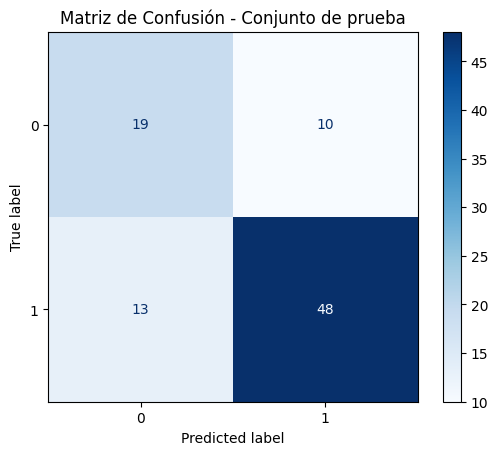

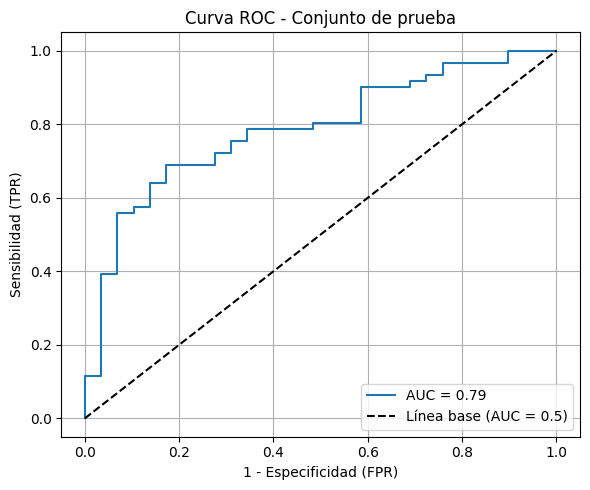

In [102]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Preparar X_test con las mismas columnas que X_modelo
X_test_modelo = X_test[columnas_modelo].copy()

# Predicciones y probabilidades sobre el set de prueba
y_pred_test = modelo.predict(X_test_modelo)
y_prob_test = modelo.predict_proba(X_test_modelo)[:, 1]

# --- 1. Matriz de confusión ---
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
plt.figure(figsize=(5, 4))
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Conjunto de prueba")
plt.grid(False)
plt.show()

# --- 2. Curva ROC ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
auc = roc_auc_score(y_test, y_prob_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--', label="Línea base (AUC = 0.5)")
plt.xlabel('1 - Especificidad (FPR)')
plt.ylabel('Sensibilidad (TPR)')
plt.title('Curva ROC - Conjunto de prueba')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [103]:
import ipywidgets as widgets
from ipywidgets import interact
import pandas as pd
import matplotlib.pyplot as plt

# Función de predicción
def predecir_neumonia(
    edad, sexo, fiebre, tos, infiltrado_rx, engrosamiento_parietal,
    foco_condensacion, patron_intersticial, derrame_pleural,
    broncograma_aereo, cruza_cisuras, leucocitosis, pcr,
    indice_rx, temperatura
):
    # Crear diccionario en base a columnas del modelo
    nuevo_paciente_dict = {col: 0 for col in columnas_modelo}
    nuevo_paciente_dict.update({
        'edad': edad,
        'sexo_M': 1 if sexo == 'M' else 0,
        'fiebre': fiebre,
        'tos': tos,
        'infiltrado_rx': infiltrado_rx,
        'engrosamiento_parietal': engrosamiento_parietal,
        'foco_condensacion': foco_condensacion,
        'patron_intersticial': patron_intersticial,
        'derrame_pleural': derrame_pleural,
        'broncograma_aereo': broncograma_aereo,
        'cruza_cisuras': cruza_cisuras,
        'leucocitosis': leucocitosis,
        'pcr': pcr,
        'indice_rx': indice_rx,
        'temperatura': temperatura
    })

    # Crear DataFrame con orden correcto
    nuevo_paciente = pd.DataFrame([nuevo_paciente_dict], columns=columnas_modelo)

    # Predicción
    pred = modelo.predict(nuevo_paciente)[0]
    prob = modelo.predict_proba(nuevo_paciente)[0][1]

    # Mostrar resultado
    print("¿Tiene neumonía este paciente?")
    print(f"✔️ Predicción: {'Sí' if pred == 1 else 'No'}")
    print(f"📊 Probabilidad estimada: {prob:.2%}")

    # Visualización
    plt.bar(['No Neumonía', 'Neumonía'], modelo.predict_proba(nuevo_paciente)[0], color=['gray', 'blue'])
    plt.ylim(0, 1)
    plt.ylabel('Probabilidad')
    plt.title(f'PCR={pcr} mg/L | Temp={temperatura}°C | Edad={edad} años')
    plt.grid(True, axis='y')
    plt.show()

# Crear sliders y desplegables
interact(predecir_neumonia,
         edad=widgets.IntSlider(min=18, max=100, step=1, value=56),
         sexo=widgets.Dropdown(options=['F', 'M'], value='F'),
         fiebre=widgets.IntSlider(min=0, max=1, step=1, value=0),
         tos=widgets.IntSlider(min=0, max=1, step=1, value=1),
         infiltrado_rx=widgets.IntSlider(min=0, max=1, step=1, value=0),
         engrosamiento_parietal=widgets.IntSlider(min=0, max=1, step=1, value=0),
         foco_condensacion=widgets.IntSlider(min=0, max=1, step=1, value=0),
         patron_intersticial=widgets.IntSlider(min=0, max=1, step=1, value=1),
         derrame_pleural=widgets.IntSlider(min=0, max=1, step=1, value=0),
         broncograma_aereo=widgets.IntSlider(min=0, max=1, step=1, value=1),
         cruza_cisuras=widgets.IntSlider(min=0, max=1, step=1, value=1),
         leucocitosis=widgets.IntSlider(min=4000, max=20000, step=500, value=12000),
         pcr=widgets.IntSlider(min=0, max=100, step=1, value=43),
         indice_rx=widgets.FloatSlider(min=0.0, max=1.0, step=0.01, value=0.6),
         temperatura=widgets.FloatSlider(min=35.0, max=41.0, step=0.1, value=37.8)
        );

interactive(children=(IntSlider(value=56, description='edad', min=18), Dropdown(description='sexo', options=('…

# Explicabilidad

¿Cuáles son las variables más relevantes para hacer el diagnóstico de neumonía?

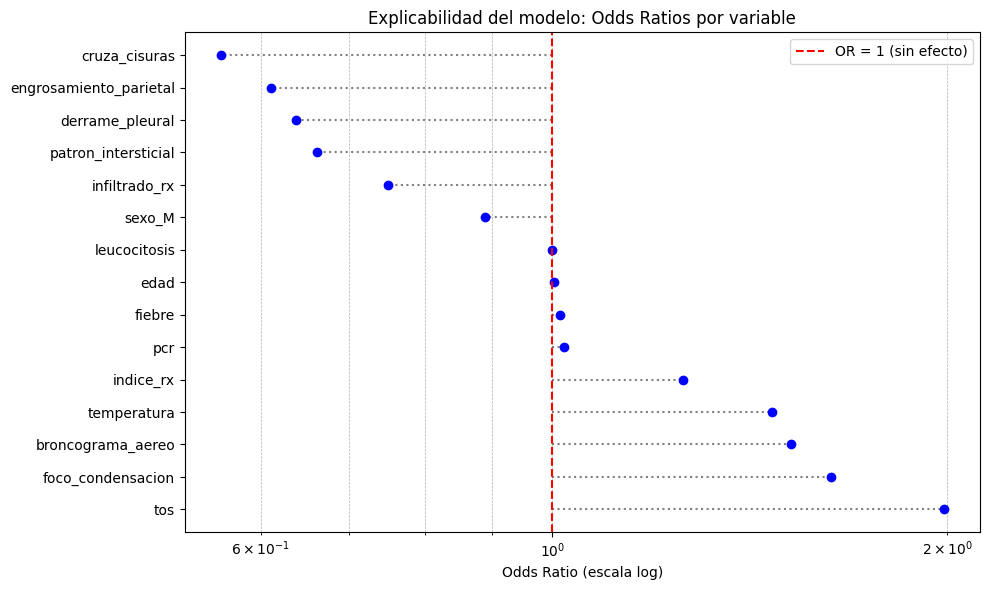

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Obtener coeficientes y calcular OR
coefs = modelo.coef_[0]
odds_ratios = np.exp(coefs)

# Crear DataFrame para visualización
df_or = pd.DataFrame({
    'Variable': columnas_modelo,
    'OR': odds_ratios,
    'log(OR)': coefs
}).sort_values(by='OR', ascending=False)

# Graficar como boxplot horizontal (simulado como gráfico de puntos con escala logarítmica)
plt.figure(figsize=(10, 6))
plt.hlines(y=df_or['Variable'], xmin=1, xmax=df_or['OR'], color='gray', linestyles='dotted')
plt.plot(df_or['OR'], df_or['Variable'], 'o', color='blue')
plt.axvline(x=1, color='red', linestyle='--', label='OR = 1 (sin efecto)')

plt.xscale('log')  # Escala logarítmica para mejor visualización
plt.xlabel('Odds Ratio (escala log)')
plt.title('Explicabilidad del modelo: Odds Ratios por variable')
plt.grid(True, which='both', axis='x', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()